Creating the pipeline and the model. Training the model

In [135]:
import numpy as np
from src.ai_lib import layers
from src.ai_lib import Sequential, Model
from src.ai_lib import losses
from src.ai_lib import optimizers
from src.ai_lib import metrics

def load_local_mnist(images_path):
    with open(images_path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    
    X = data.reshape(-1, 1, 28, 28) / 255.0
    
    return X.astype(np.float32)

X_train = load_local_mnist('data/mnist/train-images.idx3-ubyte')
X_val = load_local_mnist('data/mnist/t10k-images.idx3-ubyte')

vae = Sequential([
                  # Encoder
                  layers.Conv2d(1, out_channels=16, kernel_size=3, stride=2, padding=1), # Output: (B, 16, 14, 14)
                  layers.ReLU(),
                  layers.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # Output: (B, 32, 7, 7)
                  layers.ReLU(),

                  layers.Flatten(),
                  layers.Linear(32 * 7 * 7, 32),

                  # Latent space 
                  layers.SamplingLayer(kl_weight = 0.01),

                  # Decoder
                  layers.Linear(16, 16 * 7 * 7),
                  layers.ReLU(),
                  layers.Reshape((16, 7, 7)),

                  layers.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1), # Output: (B, 8, 14, 14)
                  layers.ReLU(),
                  layers.ConvTranspose2d(8, 1, kernel_size=4, stride=2, padding=1), # Output: (B, 1, 28, 28)
                  layers.Sigmoid()
                  ])

model = Model(vae)
model.fit(X_train, X_train, 50, losses.BinaryCrossEntropy(), optimizers.Adam(learning_rate=0.0005, weight_decay=0.01), batch_size=16, accumulation_steps=4, validation_data=[X_val, X_val], early_stopping=True, patience=4)



Iteration 0 completed, loss is 0.3272139816461519
Iteration 0 completed, validation loss is 0.29700063542164784
Iteration 1 completed, loss is 0.26681247137638403
Iteration 1 completed, validation loss is 0.28180995102806294
Iteration 2 completed, loss is 0.26513625668183594
Iteration 2 completed, validation loss is 0.27184932614347446
Iteration 3 completed, loss is 0.26436293470757855
Iteration 3 completed, validation loss is 0.26735514700183793
Iteration 4 completed, loss is 0.26393440547543984
Iteration 4 completed, validation loss is 0.2655127278006013
Iteration 5 completed, loss is 0.26365013070011406
Iteration 5 completed, validation loss is 0.26416610290535353
Iteration 6 completed, loss is 0.2634938850167447
Iteration 6 completed, validation loss is 0.26355969518833244
Iteration 7 completed, loss is 0.2633647658474804
Iteration 7 completed, validation loss is 0.263158149338674
Iteration 8 completed, loss is 0.26324766619579376
Iteration 8 completed, validation loss is 0.2630157

Génération d'images

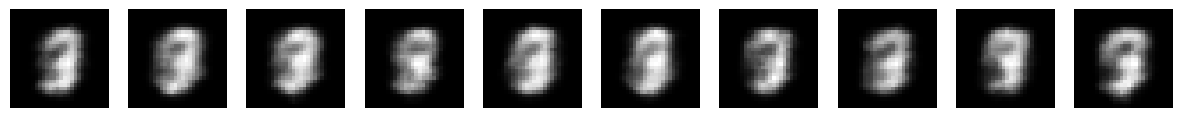

In [174]:
import matplotlib.pyplot as plt

decoder_layers = vae.layers[-7:]

decoder = Sequential(decoder_layers)
decoder.set_training(False)

# Sampling points in the latent space purely randomly to see what it leads to
random_latent_vectors = np.random.randn(10, 16).astype(np.float32) * 6

generated_images = decoder.forward(random_latent_vectors)

# Plotting
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    # Removing the batch dimension
    img = generated_images[i].squeeze()
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

plt.show()